In [1]:
# Updated Version

import os
import re
import pandas as pd
from ase.io import read, write
from ase import Atoms
import numpy as np
import random as r
import sys
from collections import defaultdict, deque

def near(atomnum, atoms, tolerance=2.000, Cfirst=True):
    atoms_not_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
    mole = [atomnum]
    pre_distances = atoms.get_distances(atomnum, atoms_not_H)
    distances = np.delete(pre_distances, np.where(pre_distances >= tolerance))
    distances = np.delete(distances, np.where(distances == 0))
    distances.sort()
    length = len(distances)
    if length > 4:
        distances = distances[:4]
    for i, atom in enumerate(atoms_not_H):
        distance = atoms.get_distance(atom, atomnum)
        if distance in distances:
            mole.append(atom)
    mole_C = []
    mole_other = []
    for num in mole:
        if atoms[num].symbol == 'C':
            mole_C.append(num)
        else:
            mole_other.append(num)
    if len(distances) == 1:
        if atoms[atomnum].symbol == 'C':
            return mole_C + mole_other
        else:
            return mole_other + mole_C
    if Cfirst == True:
        return mole_C + mole_other
    else:
        return mole_other + mole_C

def allone(lists):
    judge_box = []
    for ls in lists:
        for i in ls:
            judge_box.append(i)
    if 0 in judge_box:
        return 0
    else:
        return 1

def allroutes(file, loc='./', atomnums=[0,1], tolerance=2.000,\
              form='XYZ', Cfirst=True, ignores=[], verbose=False):
    passeds = []
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    atomnum1 = atomnums[0]
    atomnum2 = atomnums[1]
    atoms_not_H = []
    atoms_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
        else:
            atoms_H.append(i)
    
    #Trace Back
    step = 1
    z = 1
    i = 1
    passed = []
    routes = []
    real_moles = []
    route = [atomnum1]
    while 1:
        mole = near(atomnum1, atoms, tolerance=tolerance, Cfirst=Cfirst)
        if verbose == True:
            print('Near:', mole)
        real_mole = [*mole]
        real_mole.remove(atomnum1)
        real_moles.append(real_mole)
        passed = [0]*len(real_mole)
        passeds.append(passed)
        
        if verbose == True:
            print(1)
            print('Real Near:', real_mole)
            print('Passed:', passeds)
            print('Number:', real_moles)
            print('Route:', route)
            print()
        
        for i,p in enumerate(passeds[step-1]):
            if real_moles[step-1][i] in ignores:
                passeds[step-1][i] = 1
            if real_moles[step-1][i] in route:
                passeds[step-1][i] = 1
        
        if allone(passeds) == 1:
            break
        
        while 0 not in passeds[step-1]:
            del passeds[-1]
            step = step - 1
            del route[-1]
            del real_moles[-1]
        
        for j, p in enumerate(passeds[step-1]):
            if p == 0:
                break
        
        passeds[step-1][j] = 1
        atomnum1 = real_moles[step-1][j]
        route.append(atomnum1)
        if verbose == True:
            print(2)
            print('Real Near:', real_moles[step-1])
            print('Passed:', passeds)
            print('Number:', real_moles)
            print('Route:', route)
            print()
        
        if route[-1] == atomnum2:
            print('\nCorrect Route:', route)
            routes.append([*route])
            print('\n')
        
        step = step + 1

        z = z + 1
    if verbose == True:
        print(z, 'steps to find these routes.')
        print('Routes:', routes)
    os.chdir(opath)
    return routes

def routelength(file, a, loc='./'):
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    distance = 0
    for i in range(len(a)-1):
        x1 = a[0]
        x2 = a[1]
        distance = distance + atoms.get_distances(x1, x2)[0]
    os.chdir(opath)
    return distance

In [3]:
# Old Version

import os
import re
import pandas as pd
from ase.io import read, write
from ase import Atoms
import numpy as np
import random as r
import sys
from collections import defaultdict, deque

def near(atomnum, atoms, tolerance=2.000, Cfirst=True):
    atoms_not_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
    mole = [atomnum]
    pre_distances = atoms.get_distances(atomnum, atoms_not_H)
    distances = np.delete(pre_distances, np.where(pre_distances >= tolerance))
    distances = np.delete(distances, np.where(distances == 0))
    distances.sort()
    length = len(distances)
    if length > 4:
        distances = distances[:4]
    for i, atom in enumerate(atoms_not_H):
        distance = atoms.get_distance(atom, atomnum)
        if distance in distances:
            mole.append(atom)
    mole_C = []
    mole_other = []
    for num in mole:
        if atoms[num].symbol == 'C':
            mole_C.append(num)
        else:
            mole_other.append(num)
    if len(distances) == 1:
        if atoms[atomnum].symbol == 'C':
            return mole_C + mole_other
        else:
            return mole_other + mole_C
    if Cfirst == True:
        return mole_C + mole_other
    else:
        return mole_other + mole_C

def randomroute(file, loc='./', atomnums=[0,1], tolerance=2.000,\
             form='XYZ', Cfirst=True, ignores=[], verbose=False):
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    atomnum1 = atomnums[0]
    atomnum2 = atomnums[1]
    atoms_not_H = []
    atoms_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
        else:
            atoms_H.append(i)
    mole = near(atomnum1, atoms, tolerance=tolerance, Cfirst=Cfirst)
    i = 1
    if verbose == True:
        print('Near:', mole)
    real_mole = [*mole]
    real_mole.remove(atomnum1)
    for num in ignores:
        try:
            real_mole.remove(num)
        except:
            pass
    if verbose == True:
        print('Real Near:', real_mole)
    ignores.append(atomnum1)
    os.chdir(opath)
    if atomnum2 in mole:
        return [atomnum1, atomnum2]
    elif len(real_mole) == 1:
        return [atomnum1, *randomroute(file, loc=loc, atomnums=[real_mole[0], atomnum2], tolerance=tolerance,\
                form=form, Cfirst=Cfirst, ignores=ignores, verbose=verbose)]
    elif len(real_mole) >= 2:
        dice = r.randint(0, len(real_mole)-1)
        if verbose == True:
            print('Dice:', dice)
        return [atomnum1, *randomroute(file, loc=loc, atomnums=[real_mole[dice], atomnum2], tolerance=tolerance,\
                form=form, Cfirst=Cfirst, ignores=ignores, verbose=verbose)]
    elif len(real_mole) == 0:
        return [-99999]

def routelength(file, a, loc='./'):
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    distance = 0
    for i in range(len(a)-1):
        x1 = a[0]
        x2 = a[1]
        distance = distance + atoms.get_distances(x1, x2)[0]
    os.chdir(opath)
    return distance

In [2]:
def near_notH(atomnum, atoms, tolerance=1.7):
    atoms_not_7 = []
    for i, atom in enumerate(atoms):
        if atom.symbol not in ['H', 'F', 'Cl', 'Br']:
            atoms_not_7.append(i)
    mole = []
    mole_ele = []
    pre_distances = atoms.get_distances(atomnum, atoms_not_7)
    distances = np.delete(pre_distances, np.where(pre_distances == 0))
    distances.sort()
    length = len(distances)
    distances = distances[:4]
    for i, atom in enumerate(atoms_not_7):
        distance = atoms.get_distance(atom, atomnum)
        if distance in distances:
            ele1 = atoms.get_chemical_symbols()[atom]
            ele2 = atoms.get_chemical_symbols()[atomnum]
            if 'S' in [ele1, ele2]:
                if distance < tolerance + 0.45:
                    mole.append([atomnum, atom])
                    mole_ele.append([ele2, ele1])
            else:
                if distance < tolerance:
                    mole.append([atomnum, atom])
                    mole_ele.append([ele2, ele1])
    return mole, mole_ele

def all_bonds(atoms, tolerance=1.7):
    atoms_not_7 = []
    Bs = []
    Bs_ele = []
    for i, atom in enumerate(atoms):
        if atom.symbol not in ['H', 'F', 'Cl', 'Br']:
            atoms_not_7.append(i)
    for atomnum in atoms_not_7:
        mole, mole_ele = near_notH(atomnum, atoms, tolerance=tolerance)
        for dipole in mole:
            pre_dipole = [*dipole]
            dipole.sort()
            if dipole != pre_dipole:
                mole_ele.reverse()
            if dipole not in Bs:
                Bs.append(dipole)
                Bs_ele.append(mole_ele)
    return Bs, Bs_ele

In [28]:
atoms = read('./Extra/1_0.0.xyz')
mole, mole_ele = near_notH(13, atoms)
print(mole)
print(mole_ele)

[[13, 0]]
[['O', 'C']]


In [4]:
print(all_bonds(atoms, tolerance=1.7))
print(len(atoms.get_chemical_symbols()))

([[0, 1], [0, 2], [0, 13], [1, 16], [2, 3], [2, 4], [3, 6], [4, 6], [4, 11], [11, 14], [11, 15], [15, 20], [16, 17], [17, 24], [20, 21], [21, 27], [24, 30], [27, 35], [30, 31], [30, 40], [35, 36], [35, 41]], [[['C', 'O'], ['C', 'C'], ['C', 'O']], [['C', 'O'], ['C', 'C'], ['C', 'O']], [['C', 'O'], ['C', 'C'], ['C', 'O']], [['O', 'C'], ['O', 'C']], [['C', 'C'], ['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C'], ['C', 'C']], [['C', 'O'], ['C', 'O'], ['C', 'C']], [['C', 'O'], ['C', 'O'], ['C', 'C']], [['O', 'C'], ['O', 'C']], [['C', 'C'], ['C', 'O']], [['C', 'O'], ['C', 'C']], [['C', 'C'], ['C', 'O']], [['C', 'O'], ['C', 'C']], [['O', 'C'], ['O', 'C']], [['O', 'C'], ['O', 'C']], [['C', 'O'], ['C', 'C'], ['C', 'O']], [['C', 'O'], ['C', 'C'], ['C', 'O']], [['C', 'O'], ['C', 'C'], ['C', 'O']], [['C', 'O'], ['C', 'C'], ['C', 'O']]])
42


In [5]:
bonds = all_bonds(atoms, tolerance=1.7)[0]

print(bonds)

[[0, 1], [0, 2], [0, 13], [1, 16], [2, 3], [2, 4], [3, 6], [4, 6], [4, 11], [11, 14], [11, 15], [15, 20], [16, 17], [17, 24], [20, 21], [21, 27], [24, 30], [27, 35], [30, 31], [30, 40], [35, 36], [35, 41]]


In [3]:
def num_in_ring(num, ringsize):
    if num < ringsize:
        return num
    else:
        return num - ringsize

def classify_nodes_by_cycles(n, edges, atoms, simplerings=True):
    # Find all rings
    adj = [[] for _ in range(n)]
    for u, v in edges:
        adj[u].append(v)
        adj[v].append(u)
    
    all_cycles = []
    all_cycles_hide = []
    conjs = []
    visited_global = [False] * n
    #print('adj =', adj)
    
    def find_simple_cycles(start):
        visited_local = [False] * n
        stack = []
        
        def dfs(node, depth, min_node):
            visited_local[node] = True
            stack.append(node)
            
            for neighbor in adj[node]:
                if neighbor < min_node:
                    continue
                    
                if neighbor == start and depth >= 2:
                    
                    cycle = stack[:] + [start]
                    
                    min_idx = cycle.index(min(cycle))
                    normalized = tuple(cycle[min_idx:] + cycle[:min_idx])
                    if {*normalized} not in all_cycles_hide:
                        all_cycles.append(normalized)
                        all_cycles_hide.append({*normalized})
                elif not visited_local[neighbor] and neighbor >= min_node:
                    dfs(neighbor, depth + 1, min_node)
            
            stack.pop()
            visited_local[node] = False
        
        dfs(start, 0, start)
    
    # Find all rings
    for i in range(n):
        find_simple_cycles(i)
        # Avoid Repeating
        for j in range(n):
            if i in adj[j]:
                adj[j].remove(i)
    
    # Nodes to Cycles
    node_to_cycles = defaultdict(list)
    for cycle_idx, cycle in enumerate(all_cycles):
        #print(cycle_idx)
        for node in cycle[:-1]:
            if node not in node_to_cycles[node]:
                #print(cycle)
                node_to_cycles[node].append(cycle_idx)
    
    real_cycles = []
    
    if simplerings == True:
        for cycle in all_cycles:
            if len(cycle) <= 8:
                real_cycles.append(cycle)
    else:
        real_cycles = all_cycles
    
    for cycle in real_cycles:
        if len(cycle) <= 5:
            conjs.append(0)
        else:
            print(cycle)
            conjs.append(1)
            for i in range(len(cycle)):
                num1 = cycle[num_in_ring(0+i, len(cycle)-1)]
                num2 = cycle[num_in_ring(1+i, len(cycle)-1)]
                num3 = cycle[num_in_ring(2+i, len(cycle)-1)]
                num4 = cycle[num_in_ring(3+i, len(cycle)-1)]
                angle = atoms.get_dihedral(num1, num2, num3, num4)
                print(angle)
                if 1 <= angle <= 360-1:
                    conjs[-1] = 0
    return real_cycles, conjs

In [75]:
atoms = read('./Extra/2001_0.0.xyz')
bonds = all_bonds(atoms, tolerance=1.7)[0]

all_cycles, conjs = classify_nodes_by_cycles(len(atoms.get_chemical_symbols()), bonds, atoms)

for i, cycle in enumerate(all_cycles):
    print(f"Ring {i+1}: {cycle[:-1]}, {'' if conjs[i] == 1 else 'Not'} Conjugated.")

(0, 1, 4, 8, 7, 3, 0)
268.462122633185
88.24463684767807
1.5251099213899286
268.6492223802348
89.14009447953612
1.1189138005994503
268.462122633185
(3, 4, 8, 14, 11, 7, 3)
88.3399056036754
267.3230857124016
3.4916708952280207
85.7685953211213
269.9320462540897
1.5495745289919327
88.3399056036754
(7, 8, 14, 16, 15, 11, 7)
266.19397868103636
84.31809155991118
5.183054101491606
263.42841617569974
86.4117254091438
3.432733540650686
266.19397868103636
Ring 1: (0, 1, 4, 3), Not Conjugated.
Ring 2: (0, 1, 4, 8, 7, 3), Not Conjugated.
Ring 3: (3, 4, 8, 7), Not Conjugated.
Ring 4: (3, 4, 8, 14, 11, 7), Not Conjugated.
Ring 5: (7, 8, 14, 11), Not Conjugated.
Ring 6: (7, 8, 14, 16, 15, 11), Not Conjugated.
Ring 7: (11, 14, 16, 15), Not Conjugated.


In [4]:
def cond_append(items, ls):
    for item in items:
        if item not in ls:
            ls.append(item)
    return ls

route_2001 = [23,5,18,15,16,6,21,24]

atoms_2001 = [15, 16]

max_ring_on_minroute = []

for cycle in all_cycles:
    assemb = {*cycle} & {*route_2001}
    if len(assemb) >= 2:
        max_ring_on_minroute = cond_append(cycle, max_ring_on_minroute)
print(max_ring_on_minroute)

#max_ring_on_bond = []
#current_max_ring_on_bond = []
#while ?:
#    for cycle in all_cycles:
#        if atoms_2001[0] in cycle and atoms_2001[1] in cycle:
#            max_ring_on_bond.append(cycle)
            

NameError: name 'all_cycles' is not defined

In [1]:
len({1,2})

2

In [10]:
print(atoms.get_dihedral(12, 14, 28, 27))

141.4817907777525


In [5]:
#f = open('Candidates.csv', 'r')
f = open('Candidates_transfer.csv', 'r')

mols = []
lists = []

for line in f:
    if 'Molecule' in line:
        continue
    a = re.split(',', line)
    mols.append(a[0])
    a = re.search(r'\[.*?\]', line)
    if a:
        lists.append(eval(a.group(0)))
    else:
        lists.append([])

In [15]:
def eleneg(ele):
    if ele == 'C':
        info = 2.55
    elif ele == 'O':
        info = 3.44
    elif ele == 'N':
        info = 3.04
    elif ele == 'S':
        info = 2.58
    elif ele == 'F':
        info = 4.00
    return info

def bonds_in_route(atoms, ls, tolerance=1.7):
    lengths = []
    pair_ele = []
    pair_num = []
    lengths_with_S = []
    pair_ele_with_S = []
    pair_num_with_S = []
    for i,atom in enumerate(ls):
        if i >= len(ls) - 1:
            break
        num1 = ls[i]
        num2 = ls[i+1]
        ele1 = atoms.get_chemical_symbols()[num1]
        ele2 = atoms.get_chemical_symbols()[num2]
        d = atoms.get_distances(num1, num2)
        if 'S' in [ele1, ele2]:
            if d > tolerance + 0.45:
                continue
            else:
                lengths_with_S.append(d)
                pair_ele_with_S.append([ele1, ele2])
                pair_num_with_S.append([num1, num2])
        else:
            if d > tolerance:
                continue
            else:
                lengths.append(d)
                pair_ele.append([ele1, ele2])
                pair_num.append([num1, num2])
    return lengths, pair_ele, pair_num, lengths_with_S, pair_ele_with_S, pair_num_with_S

def standardise_bonds(lengths, pair_ele):
    CC = 1.528
    CO = 1.407
    CN = 1.457
    OO = 1.442
    NN = 1.473
    NO = 1.431
    SS = 2.100
    SO = 1.690
    SN = 1.734
    SC = 1.830
    standardised_lengths = []
    for i, length in enumerate(lengths):
        if {*pair_ele[i]} == {'C', 'C'}:
            standardised_lengths.append(length / CC)
        elif {*pair_ele[i]} == {'N', 'N'}:
            standardised_lengths.append(length / NN)
        elif {*pair_ele[i]} == {'O', 'O'}:
            standardised_lengths.append(length / OO)
        elif {*pair_ele[i]} == {'C', 'O'}:
            standardised_lengths.append(length / CO)
        elif {*pair_ele[i]} == {'C', 'N'}:
            standardised_lengths.append(length / CN)
        elif {*pair_ele[i]} == {'O', 'N'}:
            standardised_lengths.append(length / NO)
        elif {*pair_ele[i]} == {'S', 'S'}:
            standardised_lengths.append(length / SS)
        elif {*pair_ele[i]} == {'S', 'N'}:
            standardised_lengths.append(length / SN)
        elif {*pair_ele[i]} == {'S', 'O'}:
            standardised_lengths.append(length / SO)
        elif {*pair_ele[i]} == {'S', 'C'}:
            standardised_lengths.append(length / SC)
        else:
            standardised_lengths.append(None)
    return standardised_lengths

def sulphur_result(pair_ele_with_S, pair_num_with_S, atoms):
    SS = 2.100
    SO = 1.690
    SN = 1.734
    SC = 1.830
    
    score = []
    cands = []
    cands_ele = []
    cands_length = []
    best_nums_S = []
    best_eles_S = []
    best_lengths_S = []
    
    real_length = -100.0
    for i,pair in enumerate(pair_ele_with_S):
        if pair == ['S', 'S']:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            if d / SS > real_length :
                real_length = d / SS
            cands.append(pair_ele_with_S[i])
            cands_length.append(d / SS)
        else:
            continue
    if cands != []:
        if len(cands) == 1:
            print('Broken Bonds:', cands)
            return cands
        for i, cand in enumerate(cands):
            if real_length - cands_length[i] < 0.01:
                best.append(cands)
        #print('Broken Bonds:', best)
        return best
    
    for i,pair in enumerate(pair_ele_with_S):
        if {*pair} == {'S', 'O'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SO > real_length:
                real_length = d / SO
            cands_length.append(d / SO)
            cands_ele.append(pair_ele_with_S[i])
        elif {*pair} == {'S', 'N'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SN > real_length:
                real_length = d / SN
            cands_length.append(d / SN)
            cands_ele.append(pair_ele_with_S[i])
        elif {*pair} == {'S', 'C'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SC > real_length:
                real_length = d / SC
            cands_length.append(d / SC)
            cands_ele.append(pair_ele_with_S[i])
        else:
            raise Exception('Current not support for other bonds with S.')
    
    if len(cands) == 1:
        #print('Broken Bonds:', cands)
        return cands
    #print(cands)
    #print(cands_length)
    #print(real_length)
    for i,cand in enumerate(cands):
        if real_length - cands_length[i] < 0.001:
            best_nums_S.append(cand)
            best_eles_S.append(cands_ele[i])
            best_lengths_S.append(cands_length[i])
    #print('Broken Bonds:', best_nums_S)
    
    return best_lengths_S, best_eles_S, best_nums_S

def filter_rank(file, ls, loc='./', tolerance=1.7, quick_S=True):
    atoms = read(loc+file+'.xyz')
    lengths, pair_ele, pair_num, lengths_with_S,\
    pair_ele_with_S, pair_num_with_S = bonds_in_route(atoms, ls, tolerance=tolerance)
    #print(lengths)
    #print(pair_ele)
    #print(pair_num)
    
    ## Rings Infos
    
    bonds = all_bonds(atoms, tolerance=1.7)[0]
    all_rings, conjs_ring = classify_nodes_by_cycles(len(atoms.get_chemical_symbols()), bonds, atoms, simplerings=True)
    #print(all_rings)
    #print(conjs_ring)
    
    ## Rings
    atoms_inring = []
    atoms_inconj = []
    eliminated_bonds = []
    tense_bonds = []
    
    for i, ring in enumerate(all_rings):
        if conjs_ring[i] == 1:
            for i, atom in enumerate(ring):
                if i == len(ring)-1:
                    break
                else:
                    a = ring[i]
                    b = ring[i+1]
                eliminated_bonds.append([a, b])
                eliminated_bonds.append([b, a])
                atoms_inconj.append(a)
        elif len(ring) <= 6:
            for i, atom in enumerate(ring):
                if i == len(ring)-1:
                    break
                else:
                    a = ring[i]
                    b = ring[i+1]
                tense_bonds.append([a, b])
                tense_bonds.append([b, a])
    
    #print(eliminated_bonds)
    ## Delete Bonds in Conjugative Rings
    eliminated_i = []
    for i, length in enumerate(lengths):
        if pair_num[i] in eliminated_bonds:
            eliminated_i.append(i)
    
    eliminated_i.reverse()
    for i in eliminated_i:
        del pair_num[i]
        del pair_ele[i]
        del lengths[i]
    
    eliminated_i = []
    for i, length in enumerate(lengths_with_S):
        if pair_num_with_S[i] in eliminated_bonds:
            eliminated_i.append(i)
    
    eliminated_i.reverse()
    
    for i in eliminated_i:
        #print(pair_num_with_S[i])
        del pair_num_with_S[i]
        del pair_ele_with_S[i]
        del lengths_with_S[i]
    
    ## Special: Get Result about Sulphur Bonds
    if pair_ele_with_S != [] and quick_S == True:
        #print(pair_ele_with_S)
        #print(pair_num_with_S)
        #print(lengths_with_S)
        return sulphur_result(pair_ele_with_S, pair_num_with_S, atoms)
    else:
        # Other Bonds
        pair_ele = pair_ele + pair_ele_with_S
        pair_num = pair_num + pair_num_with_S
        lengths = lengths + lengths_with_S
        #print(pair_ele)
        #print(pair_num)
        #print(lengths)
    
    ## Standardise Bonds
    standardised_lengths = standardise_bonds(lengths, pair_ele)
    
    ## Set Bonds in Other Ring:
    cand_bonds_tense = []
    
    cand_atoms_tense = []
    cand_atoms_conj = []
    
    for i, length in enumerate(lengths):
        # Atoms in Conjugative System
        atom_conj = []
        if pair_num[i][0] in atoms_inconj:
            atom_conj.append(1)
        else:
            atom_conj.append(0)
        if pair_num[i][1] in atoms_inconj:
            atom_conj.append(1)
        else:
            atom_conj.append(0)
        cand_atoms_conj.append(atom_conj)
        
        # Atoms and Bonds in rings
        minring1 = 7
        minring2 = 7
        minring3 = 7
        for ring in all_rings:
            if pair_num[i][0] in ring and len(ring) - 1 < minring1:
                minring1 = len(ring) - 1
            if pair_num[i][1] in ring and len(ring) - 1 < minring2:
                minring2 = len(ring) - 1
            if (pair_num[i][0] in ring and pair_num[i][1] in ring) and len(ring) - 1 < minring3:
                minring3 = len(ring) - 1
        atom_ring = [minring1, minring2]
        cand_atoms_tense.append(atom_ring)
        cand_bonds_tense.append(minring3)
        
    ## Rank Pairs in rings and not in rings
    # Assemble
    assembles_normal = []
    assembles_tense = []
    SignS = 0
    for i, tense in enumerate(cand_bonds_tense):
        if SignS == 1 and (pair_ele[i][0] != 'S' and pair_ele[i][1] != 'S'):
            continue
        if SignS == 0 and (pair_ele[i][0] == 'S' or pair_ele[i][1] == 'S'):
            assembles_tense = []
            assembles_normal = []
            SignS = 1
        if tense < 7:
            assembles_tense.append([
                                    lengths[i],\
                                    standardised_lengths[i], cand_bonds_tense[i],\
                                    # Standardised Bond Length, Which Ring is Bond in?
                                    eleneg(pair_ele[i][0]), eleneg(pair_ele[i][1]), \
                                    # Electronegativity of Two Atoms
                                    *cand_atoms_conj[i], \
                                    # Are Two Atoms in Conjugative Rings?
                                    *cand_atoms_tense[i], \
                                    # Which Ring are Two Atoms in?
                                    
                                    # ? Need two charges here ?
                
                                    pair_num[i], \
                                    # Atoms Number
                                    i # Bond Number
                                   ]) # 8 Indexes in all
        else:
            assembles_normal.append([
                                    lengths[i],\
                                    standardised_lengths[i], cand_bonds_tense[i], \
                                    # Standardised Bond Length, Which Ring is Bond in?
                                    eleneg(pair_ele[i][0]), eleneg(pair_ele[i][1]), \
                                    # Electronegativity of Two Atoms
                                    *cand_atoms_conj[i], \
                                    # Are Two Atoms in Conjugative Rings?
                                    *cand_atoms_tense[i], \
                                    # Which Ring are Two Atoms in?
                                    
                                    # ? Need two charges here?
                                    
                                    pair_num[i], \
                                    # Atoms Number
                                    i
                                    # Bond Number
                                   ]) # 8 Indexes in all
    
    best_cands = []
    
    i = 0
    ## Tensed Bond for 4
    assembles_tense.sort()
    assembles_tense.reverse()
    for i0,assemble_tense in enumerate(assembles_tense):
        try:
            best_cands.append(assembles_tense[i0])
        except:
            break
        i = i + 1
    
    ## Other Bonds for 5
    #print('pre', assembles_normal)
    assembles_normal.sort()
    assembles_normal.reverse()
    #print(assembles_normal)
    x = 0
    for i0,assemble_normal in enumerate(assembles_normal):
        try:
            best_cands.append(assembles_normal[x])
        except:
            break
        i = i + 1
        x = x + 1
    
    print(f'\nTop {i} possible broken bonds:\n')
    i = 1
    for cand in best_cands:
        print(f'Bond {i}:')
        print('Bond Pair: {0:>10} ,    Bond Elements: {1:>10}'.format(str(pair_num[cand[-1]]), str(pair_ele[cand[-1]])))
        print('Length: {0:>10.4f} Å,   Standardised Length: {1:>10.4%}'.format(lengths[cand[-1]][0], cand[1][0]))
        print('Minimum Ring of bond: {0},'.format(str(cand[2])))
        print('Atom 1 is {0} conjugative ring.'.format('in' if cand[5] == 1 else 'not in'))
        print('Atom 2 is {0} conjugative ring.'.format('in' if cand[6] == 1 else 'not in'))
        print('Atom 1 is {0} ring.'.format('in {0}-membered'.format(cand[7]) if cand[7] != 7 else 'not in'))
        print('Atom 2 is {0} ring.'.format('in {0}-membered'.format(cand[8]) if cand[8] != 7 else 'not in'))
        print()
        i = i + 1
    
    return best_cands

In [7]:
# Risk about NN, NO and OO

num = 127

print(mols[num])

4122


In [19]:
print(mols[num])
print(lists[num])
loc = './Extra/'

print('Broken Bonds:', filter_rank('{0}_0.0'.format(mols[num]), lists[num], loc=loc, quick_S=False))

2289
[30, 24, 21, 11, 68, 69, 53, 49, 42, 36]
(0, 1, 2, 5, 4, 3, 0)
359.8405277023448
0.5742299417888853
359.45153413985213
0.08952177804269744
0.33057109117472777
359.7015484894477
359.8405277023448
(4, 5, 10, 12, 11, 4)
0.38988717068965006
0.6600445134476085
358.6639488081075
1.5828759304699966
358.71476591939546
0.38988717068965006
(10, 12, 15, 16, 14, 13, 10)
359.15855563461355
0.10536296497000576
0.42459253245492806
359.7914772480547
359.4713881433811
1.0677108306213092
359.15855563461355
(21, 22, 23, 24, 25, 26, 21)
359.8442826965377
0.6021706451396868
359.8721129689395
359.17220157475714
1.305274114700613
359.1712311176818
359.8442826965377
(38, 42, 48, 51, 49, 44, 38)
359.04174331865005
0.21478644712448552
1.0743832901748434
358.4742276213153
0.7131252034612923
0.5281882373168716
359.04174331865005
(43, 45, 50, 55, 54, 46, 43)
359.91420388746064
0.5337162373635026
359.4411279207613
0.15395427468291384
0.29295256567528355
359.67578045338234
359.91420388746064
(50, 53, 58, 59, 55

In [2]:
atoms = read('./Extra/ir/xyz/1_0.0.xyz')
atomnum = 31

print(near(atomnum, atoms, tolerance=2.000, Cfirst=True))

NameError: name 'read' is not defined

In [61]:
print(abs(1.88163809-1.88064718))
print(abs(1.79791911-1.79729475))

0.000990910000000067
0.0006243599999999905


In [58]:
abs(1.0282175375059246-1.0276760547662396)

0.0005414827396850175

In [64]:
abs(1.0058132978263234-1.0052585733161603)

0.0005547245101631404

In [16]:
# Prepare Training Set

import os
import re
import pandas as pd

f = open('Candidates_transfer.csv', 'r')
mols = []
lists = []

for line in f:
    if 'Molecule' in line:
        continue
    a = re.split(',', line)
    mols.append(a[0])
    a = re.search(r'\[.*?\]', line)
    if a:
        lists.append(eval(a.group(0)))
    else:
        lists.append([])

f.close()

The file about former experiment:

In [ ]:
all_i = []
orblocs = []

csv = pd.read_csv('2d.csv')

Molnums = csv['Molecule'].tolist()

SMILESbox = csv['SMILES'].tolist()
Force = csv['Force'].tolist()
Force0 = [[force] for force in Force]
Type = csv['Predicted Type'].tolist()
Type0 = [[typ] for typ in Type]
Result = csv['Result'].tolist()
Result0 = [[res] for res in Result]

Atom1s = csv['BeginAtom'].tolist()
Atom2s = csv['EndAtom'].tolist()
Broken_bonds1_1 = csv['atom1'].tolist()
Broken_bonds2_1 = csv['atom2'].tolist()
Broken_bonds1_2 = csv['atom1_2'].tolist()
Broken_bonds2_2 = csv['atom2_2'].tolist()
Broken_bonds1_3 = csv['atom1_3'].tolist()
Broken_bonds2_3 = csv['atom2_3'].tolist()
Broken_bonds1_4 = csv['atom1_4'].tolist()
Broken_bonds2_4 = csv['atom2_4'].tolist()

csv2 = pd.read_csv('./Extra/RFT.csv')

Molnums2 = csv2['Molecule'].tolist()
Es_0_0 = csv2['E_0.0'].tolist()
Es_0_5 = csv2['E_0.5'].tolist()
Es_1_0 = csv2['E_1.0'].tolist()

In [17]:
w = open('Force_candidate_transfer3.csv', 'w')
w.write('Molecule,Atom 1,Atom 2,Bond Length,Standardised Bond Length,InRing_B,Elecneg_1,Elecneg_2,InConj_1,InConj_2,InRing_1,InRing_2\n')

ox = 0
for num,mol in enumerate(mols):
    if mol == '4091':
        ox = 1
    if ox == 0:
        continue
#    if mol == '4007':
#        pass
#    else:
#        continue
    #    break
    
    print('Molecule {0}:'.format(mol))
    cands = filter_rank('{0}_0.0'.format(mols[num]), lists[num], loc='./Extra/ir/xyz/', quick_S=False)
    for cand in cands:
        try:
            cand[1][0] + 1
            print(cand[1][0] + 1)
        except:
            continue
        w.write('{0},'.format(mol)) # Molecule
        w.write('{0},{1},'.format(*cand[-2])) # Bond Pair
        w.write('{0},'.format(cand[0][0])) # bond length
        w.write('{0},'.format(cand[1][0])) # Standardised bond length
        w.write('{0},'.format(cand[2])) # Which Ring is Bond in?
        w.write('{0},{1},'.format(cand[3], cand[4])) # Electronegativity of Two Atoms
        w.write('{0},{1},'.format(cand[5], cand[6])) # Are Two Atoms in Conjugative Rings?
        w.write('{0},{1}'.format(cand[7], cand[8])) # Which Ring are Two Atoms in?
        w.write('\n')
    break
w.close()

Molecule 4091:
(0, 1, 2, 5, 3, 0)
359.9319615459098
358.8214921655989
1.842933641854281
358.10325184740043
1.1400301933611372
359.9319615459098
(4, 36, 40, 39, 38, 37, 4)
359.81309971871565
359.8617267985077
0.37219806940073197
359.70977186339155
359.95534008939796
0.27913677691612193
359.81309971871565
(6, 8, 9, 10, 12, 11, 6)
359.23812322912084
359.86395897898103
0.73919454790192
359.53954449161216
359.5847975392442
1.0305637918903192
359.23812322912084
(7, 17, 19, 21, 20, 18, 7)
359.61383334919094
0.47177981147875797
0.09911819519934288
359.2270827628046
0.8503696109469391
359.733131523601
359.61383334919094
(36, 40, 42, 43, 44, 45, 36)
0.4031464135053234
359.92383086419113
359.75862592457577
0.22429094619671813
0.10500650080282337
359.5924517457524
0.4031464135053234
(38, 39, 50, 51, 52, 53, 38)
359.9004483941708
359.9977081768035
0.09654415591337036
359.9137103076585
359.9810689599273
0.10886553821370246
359.9004483941708
(58, 59, 60, 63, 61, 58)
2.0603785616062154
358.54581444101

In [16]:
1.3533/96.1844*100

1.4069849164729415

In [48]:
w = open('isbroken_part.csv', 'w')

csv1 = pd.read_csv('route.csv')
#csv2 = pd.read_csv('Force_candidate.csv')
csv2 = pd.read_csv('Force_candidate_transfer.csv')

Molnums1 = csv1['Molecule'].tolist()
Broken_bonds1_1 = csv1['atom1'].tolist()
Broken_bonds2_1 = csv1['atom2'].tolist()
Broken_bonds1_2 = csv1['atom1_2'].tolist()
Broken_bonds2_2 = csv1['atom2_2'].tolist()
Broken_bonds1_3 = csv1['atom1_3'].tolist()
Broken_bonds2_3 = csv1['atom2_3'].tolist()
Broken_bonds1_4 = csv1['atom1_4'].tolist()
Broken_bonds2_4 = csv1['atom2_4'].tolist()

Molnums2 = csv2['Molecule'].tolist()
Atom1_2 = csv2['Atom 1'].tolist()
Atom2_2 = csv2['Atom 2'].tolist()

#print(Molnums2[i])
j = 0
for i, num in enumerate(Molnums2):
    print('Molecule', num)
    while str(Molnums2[i]) != Molnums1[j]:
        j = j + 1
        if j == len(Molnums1):
            break
    print(Molnums2[i], Molnums1[j])
    broken_bond1 = {Broken_bonds1_1[j], Broken_bonds2_1[j]}
    try:
        broken_bond2 = {int(Broken_bonds1_2[j]), int(Broken_bonds2_2[j])}
    except:
        broken_bond2 = {None, None}
    try:
        broken_bond3 = {int(Broken_bonds1_3[j]), int(Broken_bonds2_3[j])}
    except:
        broken_bond3 = {None, None}
    try:
        broken_bond4 = {int(Broken_bonds1_4[j]), int(Broken_bonds2_4[j])}
    except:
        broken_bond4 = {None, None}
    print(broken_bond1, broken_bond2, broken_bond3, broken_bond4)
    if {str(int(Atom1_2[i])), str(int(Atom2_2[i]))} == broken_bond1:
        w.write('{0}\n'.format(1))
    elif {Atom1_2[i], Atom2_2[i]} == broken_bond2:
        w.write('{0}\n'.format(1))
    elif {Atom1_2[i], Atom2_2[i]} == broken_bond3:
        w.write('{0}\n'.format(1))
    elif {Atom1_2[i], Atom2_2[i]} == broken_bond4:
        w.write('{0}\n'.format(1))
    else:
        w.write('{0}\n'.format(0))

w.close()

Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 1
1 1
{'2', '4'} {None} {None} {None}
Molecule 2
2 2
{'2', '4'} {None} {None} {None}
Molecule 2
2 2
{'2', '4'} {None} {None} {None}
Molecule 2
2 2
{'2', '4'} {None} {None} {None}
Molecule 2
2 2
{'2', '4'} {None} {None} {None}
Molecule 2
2 2
{'2', '4'} {None} {None} {None}
Molecule 2
2 2
{'2', '4'} {None} {None} {None}
Molecule 2
2 

IndexError: list index out of range

In [ ]:
# Problems of Rhodamine is serious.

# Molecule 120 max angle is 1.8 degree.
# Molecule ???? max angle is ??? degree.

In [46]:
# non-Hydrogen Neighours

#csv = pd.read_csv('Force_candidate.csv')
csv = pd.read_csv('Force_candidate_transfer3.csv')
#csv = pd.read_csv('./generalization/final_isbroken_test_complete_transfer.csv')

w = open('sp.csv', 'w')

Molnums = csv['Molecule'].tolist()

Atom1s = csv['Atom 1'].tolist()
Atom2s = csv['Atom 2'].tolist()

w.write('Molecule,Atom1,Atom2,Neighbour1,Neighbour2,Bond Length,Standardised Bond Length\n')

for i, Molnum in enumerate(Molnums):
    print('Molecule', Molnum)
    atoms = read('./Extra/ir/xyz/{0}_0.0.xyz'.format(Molnum))
    atomnum1 = int(Atom1s[i])
    ele1 = atoms.get_chemical_symbols()[atomnum1]
    if ele1 == 'S':
        near1 = near(atomnum1, atoms, tolerance=2.200, Cfirst=True)
    else:
        near1 = near(atomnum1, atoms, tolerance=2.000, Cfirst=True)
    print('Atom {0}: Element {1}, {2} Neighbours.'.format(atomnum1, ele1, len(near1)-1))
    atomnum2 = int(Atom2s[i])
    ele2 = atoms.get_chemical_symbols()[atomnum2]
    if ele2 == 'S':
        near2 = near(atomnum2, atoms, tolerance=2.200, Cfirst=True)
    else:
        near2 = near(atomnum2, atoms, tolerance=2.000, Cfirst=True)
    print('Atom {0}: Element {1}, {2} Neighbours.'.format(atomnum2, ele2, len(near2)-1))
    length = atoms.get_distance(atomnum1, atomnum2)
    standardised_length = standardise_bonds([length], [[ele1, ele2]])
    print('Length: {0} Å'.format(length))
    print('Standardised Length: {0:.2%}'.format(standardised_length[0]))
    print()
    w.write('{0},{1},{2},{3},{4},{5},{6}\n'.format(Molnum, atomnum1, atomnum2, len(near1)-1, len(near2)-1, length, standardised_length[0]))

w.close()

Molecule 4122
Atom 19: Element C, 4 Neighbours.
Atom 20: Element C, 3 Neighbours.
Length: 1.5890561510386143 Å
Standardised Length: 104.00%

Molecule 4122
Atom 61: Element C, 4 Neighbours.
Atom 64: Element C, 3 Neighbours.
Length: 1.588169509559435 Å
Standardised Length: 103.94%

Molecule 4122
Atom 18: Element C, 3 Neighbours.
Atom 21: Element C, 3 Neighbours.
Length: 1.5557213999948933 Å
Standardised Length: 101.81%

Molecule 4122
Atom 65: Element C, 3 Neighbours.
Atom 67: Element C, 3 Neighbours.
Length: 1.5552242082354688 Å
Standardised Length: 101.78%

Molecule 4122
Atom 20: Element C, 3 Neighbours.
Atom 21: Element C, 3 Neighbours.
Length: 1.5432291360311745 Å
Standardised Length: 101.00%

Molecule 4122
Atom 64: Element C, 3 Neighbours.
Atom 67: Element C, 3 Neighbours.
Length: 1.5431529215472979 Å
Standardised Length: 100.99%

Molecule 4122
Atom 0: Element C, 3 Neighbours.
Atom 19: Element C, 4 Neighbours.
Length: 1.5359922815731732 Å
Standardised Length: 100.52%

Molecule 4122
A

In [14]:
# non-Hydrogen Neighours

#csv = pd.read_csv('Force_candidate.csv')
#csv = pd.read_csv('Force_candidate_transfer.csv')
csv = pd.read_csv('./generalization/final_isbroken_test_complete_transfer.csv')

w = open('sp.csv', 'w')

Molnums = csv['Molecule'].tolist()

Atom1s = csv['Atom 1'].tolist()
Atom2s = csv['Atom 2'].tolist()

w.write('Molecule,Atom1,Atom2,Neighbour1,Neighbour2\n')

for i, Molnum in enumerate(Molnums):
    print('Molecule', Molnum)
    atoms = read('./Extra/ir/xyz/{0}_0.0.xyz'.format(Molnum))
    atomnum1 = int(Atom1s[i])
    ele1 = atoms.get_chemical_symbols()[atomnum1]
    if ele1 == 'S':
        near1 = near(atomnum1, atoms, tolerance=2.200, Cfirst=True)
    else:
        near1 = near(atomnum1, atoms, tolerance=2.000, Cfirst=True)
    print('Atom {0}: Element {1}, {2} Neighbours.'.format(atomnum1, ele1, len(near1)-1))
    atomnum2 = int(Atom2s[i])
    ele2 = atoms.get_chemical_symbols()[atomnum2]
    if ele2 == 'S':
        near2 = near(atomnum2, atoms, tolerance=2.200, Cfirst=True)
    else:
        near2 = near(atomnum2, atoms, tolerance=2.000, Cfirst=True)
    print('Atom {0}: Element {1}, {2} Neighbours.'.format(atomnum2, ele2, len(near2)-1))
    length = atoms.get_distance(atomnum1, atomnum2)
    #standardised_length = standardise_bonds([length], [[ele1, ele2]])
    print('Length: {0} Å'.format(length))
    #print('Standardised Length: {0:.2%}'.format(standardised_length[0]))
    print()
    w.write('{0},{1},{2},{3},{4}\n'.format(Molnum, atomnum1, atomnum2, len(near1)-1, len(near2)-1))

w.close()

Molecule 4001
Atom 5: Element C, 3 Neighbours.
Atom 6: Element C, 3 Neighbours.
Length: 1.5755118040308858 Å

Molecule 4001
Atom 2: Element C, 3 Neighbours.
Atom 6: Element C, 3 Neighbours.
Length: 1.5676862163985386 Å

Molecule 4001
Atom 4: Element C, 3 Neighbours.
Atom 5: Element C, 3 Neighbours.
Length: 1.5531160949570126 Å

Molecule 4001
Atom 3: Element C, 3 Neighbours.
Atom 4: Element C, 3 Neighbours.
Length: 1.5424639426944386 Å

Molecule 4001
Atom 1: Element C, 2 Neighbours.
Atom 2: Element C, 3 Neighbours.
Length: 1.5089803936974844 Å

Molecule 4001
Atom 0: Element C, 3 Neighbours.
Atom 3: Element C, 3 Neighbours.
Length: 1.4993089799309565 Å

Molecule 4001
Atom 2: Element C, 3 Neighbours.
Atom 28: Element O, 2 Neighbours.
Length: 1.4173339244540146 Å

Molecule 4001
Atom 4: Element C, 3 Neighbours.
Atom 28: Element O, 2 Neighbours.
Length: 1.4128716505315848 Å

Molecule 4001
Atom 0: Element C, 3 Neighbours.
Atom 1: Element C, 2 Neighbours.
Length: 1.3526871195023624 Å

Molecule

In [22]:
# Models

#csv = pd.read_csv('candidate_bonds_no_conformer.csv')
csv = pd.read_csv('candidate_bonds.csv')

Molnums = csv['Molecule'].tolist()

#Type = csv['Predicted Type'].tolist()
#Type0 = [[typ] for typ in Type]

Atom1s = csv['Atom 1'].tolist()
Atom2s = csv['Atom 2'].tolist()

length0s = csv['Bond Length'].tolist()
lengths = csv['Standardised Bond Length'].tolist()
InRing_Bonds = csv['InRing_B'].tolist()

Elecneg_atom1 = csv['Elecneg_1'].tolist()
Elecneg_atom2 = csv['Elecneg_2'].tolist()
InConj_atom1 = csv['InConj_1'].tolist()
InConj_atom2 = csv['InConj_2'].tolist()
InRing_atom1 = csv['InRing_1'].tolist()
InRing_atom2 = csv['InRing_2'].tolist()

IsBroken_Bonds = csv['IsBroken'].tolist()

KeyError: 'Bond Length'

In [23]:
# Consider Sulphur

real_Mols = []
for num in Molnums:
    if num not in real_Mols:
        real_Mols.append(num)

real_Molnum = len(real_Mols)
print(real_Molnum)

717


In [118]:
# Skip Sulphur

real_Mols = []
for i,num in enumerate(Molnums):
    if num not in real_Mols and 2.58 not in {Elecneg_atom1[i], Elecneg_atom2[i]}:
        real_Mols.append(num)

real_Molnum_skip_S = len(real_Mols)
print(real_Molnum_skip_S)

686


In [119]:
# Special Train Test Split


random_box = r.sample(range(real_Molnum_skip_S), k=real_Molnum_skip_S)# Skip Sulphur
#random_box = r.sample(range(real_Molnum), k=real_Molnum) # Normal
print(random_box)

x_train = []
#x_val = []
x_test = []
y_train = []
#y_val = []
y_test = []
train_mol = []
test_mol = []
test = []#

j = 0
for turn, mol in enumerate(Molnums):
    # Skip Sulphur
    if 2.58 in {Elecneg_atom1[turn], Elecneg_atom2[turn]}: #
        continue#
    
    if turn > 0 and mol != Molnums[turn-1]:
        j = j + 1
    randomnumber = random_box[j]
    #if randomnumber <= real_Molnum * 0.8: # Normal
    if randomnumber <= real_Molnum_skip_S * 0.8: # Skip Sulphur
        train_mol.append([mol, [Atom1s[turn], Atom2s[turn]]])
        x_train.append(np.array([length0s[turn], lengths[turn], InRing_Bonds[turn], Elecneg_atom1[turn],\
                        Elecneg_atom2[turn], InConj_atom1[turn], InConj_atom2[turn], InRing_atom1[turn], InRing_atom2[turn]]))
        y_train.append(np.array(IsBroken_Bonds[turn]))
        if randomnumber not in test:
            test.append(randomnumber)
    else:
        test_mol.append([mol, [Atom1s[turn], Atom2s[turn]]])
        x_test.append(np.array([length0s[turn], lengths[turn], InRing_Bonds[turn], Elecneg_atom1[turn],\
                       Elecneg_atom2[turn], InConj_atom1[turn], InConj_atom2[turn], InRing_atom1[turn], InRing_atom2[turn]]))
        y_test.append(np.array(IsBroken_Bonds[turn]))
        #if randomnumber not in test:
        #    test.append(randomnumber)

print(len(x_train))
print(len(x_test))

[657, 439, 616, 184, 357, 381, 574, 460, 223, 399, 336, 477, 559, 85, 442, 564, 45, 579, 264, 470, 4, 393, 362, 313, 265, 436, 255, 450, 420, 180, 646, 122, 113, 259, 70, 91, 578, 233, 195, 215, 293, 14, 217, 149, 316, 382, 572, 58, 667, 453, 106, 275, 266, 424, 503, 118, 141, 514, 515, 377, 605, 198, 134, 525, 661, 583, 311, 76, 684, 648, 619, 367, 347, 48, 237, 437, 262, 570, 408, 365, 267, 103, 659, 273, 46, 250, 240, 162, 156, 505, 404, 312, 651, 464, 615, 154, 207, 340, 179, 278, 406, 282, 123, 317, 482, 589, 465, 160, 97, 502, 147, 504, 394, 531, 662, 175, 626, 290, 556, 181, 323, 120, 302, 555, 611, 602, 305, 157, 346, 455, 331, 254, 74, 550, 339, 496, 385, 590, 599, 380, 549, 272, 129, 672, 637, 581, 526, 663, 585, 643, 379, 457, 261, 137, 674, 368, 128, 124, 679, 580, 42, 471, 24, 366, 359, 334, 30, 77, 398, 350, 87, 600, 352, 9, 349, 530, 391, 213, 369, 140, 683, 669, 165, 238, 403, 361, 297, 413, 252, 463, 190, 95, 40, 652, 660, 241, 345, 333, 447, 41, 378, 604, 528, 630, 20

In [155]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import random as r

preprocessing_pipeline = Pipeline([('scaler', StandardScaler())])

X_train_st = preprocessing_pipeline.fit_transform(np.array(x_train))
X_test_st = preprocessing_pipeline.transform(np.array(x_test))

y_train = np.array(y_train)
y_test = np.array(y_test)

In [153]:
tree = RandomForestClassifier(n_estimators=100, random_state=r.randint(1,100)).fit(X_train_st, y_train)

In [156]:
tree = XGBClassifier(n_estimators=100, learning_rate=0.04, subsample=0.5,\
                        max_depth=7, random_state=r.randint(1, 100)).fit(X_train_st, y_train)

In [21]:
## Train Accuracy
y_predict = tree.predict(X_train_st)

all_box_predicted_y = []
box_predicted_y = []
all_box_real_y = []
box_real_y = []
train_mols_details = []
test_mols_details = []
train_mol_details = []
test_mol_details = []

# Assemble
for i, mol in enumerate(train_mol):
    if i >= 1 and train_mol[i][0] != train_mol[i-1][0]:
        all_box_real_y.append(box_real_y)
        all_box_predicted_y.append(box_predicted_y)
        train_mols_details.append(train_mol_details)
        box_real_y = []
        box_predicted_y = []
        train_mol_details = []
    elif i == len(train_mol) -1:
        all_box_real_y.append(box_real_y)
        all_box_predicted_y.append(box_predicted_y)
        train_mols_details.append(train_mol_details)
    
    train_mol_details.append(train_mol[i])
    box_real_y.append(y_train[i])
    box_predicted_y.append(y_predict[i])

total = len(all_box_real_y)
#total = len(all_box_real_y) + real_Molnum - real_Molnum_skip_S # Skip Sulphur
#print(all_box_real_y)
print('Total Train Number:', len(all_box_real_y))

# Get Acc
correct = 0
#correct = correct + real_Molnum - real_Molnum_skip_S # Skip Sulphur
for i, mol in enumerate(all_box_real_y):
    if all_box_real_y[i] == all_box_predicted_y[i]:
        correct += 1
        
acc_train = correct / total

print('Train Accuracy: {0:.2%}'.format(acc_train))

## Test Accuracy
y_predict = tree.predict(X_test_st)

all_box_predicted_y = []
box_predicted_y = []
all_box_real_y = []
box_real_y = []

# Assemble
for i, mol in enumerate(test_mol):
    #print(i)
    test_mol_num = []
    if i >= 1 and test_mol[i][0] != test_mol[i-1][0]:
        all_box_real_y.append(box_real_y)
        all_box_predicted_y.append(box_predicted_y)
        test_mols_details.append(test_mol_details)
        box_real_y = []
        box_predicted_y = []
        test_mol_details = []
        
    elif i == len(test_mol) -1:
        all_box_real_y.append(box_real_y)
        all_box_predicted_y.append(box_predicted_y)
        test_mols_details.append(test_mol_details)
    
    test_mol_details.append(test_mol[i])
    box_real_y.append(y_test[i])
    box_predicted_y.append(y_predict[i])

total = len(all_box_real_y)
#total = len(all_box_real_y) + real_Molnum - real_Molnum_skip_S # Skip Sulphur
print('Total Test Number:', len(all_box_real_y))

# Get Acc
correct = 0
#correct = correct + real_Molnum - real_Molnum_skip_S # Skip Sulphur
for i, mol in enumerate(all_box_real_y):
    if all_box_real_y[i] == all_box_predicted_y[i]:
        correct += 1
        
acc_test = correct / total

print('Molecules with Sulphur:', real_Molnum - real_Molnum_skip_S)

print('Test Accuracy: {0:.2%}'.format(acc_test))

NameError: name 'tree' is not defined

In [138]:
from scipy.stats import rankdata

importances = tree.feature_importances_
print(importances)

[0.10593797 0.6776209  0.02598447 0.03277    0.02293639 0.02781959
 0.07253624 0.03439445]


In [112]:
i = 78

print('Molecule {0}:'.format(test_mols_details[i]))
print('Predicted:', all_box_real_y[i])
print('Target:', all_box_predicted_y[i])

Molecule [['2136', [4, 3]], ['2136', [3, 0]], ['2136', [6, 30]], ['2136', [37, 40]], ['2136', [21, 12]], ['2136', [36, 37]], ['2136', [30, 36]], ['2136', [12, 4]]]:
Predicted: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Target: [np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


# Unsupervised Learning

In [121]:
# t-SNE

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Downgrade the dimension

#pca = PCA(n_components=20)
#X_scaled = pca.fit_transform(FPs_rectified)

tsne = TSNE(n_components=2, perplexity=50, learning_rate=100, random_state=10)

X_embedded = tsne.fit_transform(X_train_st)

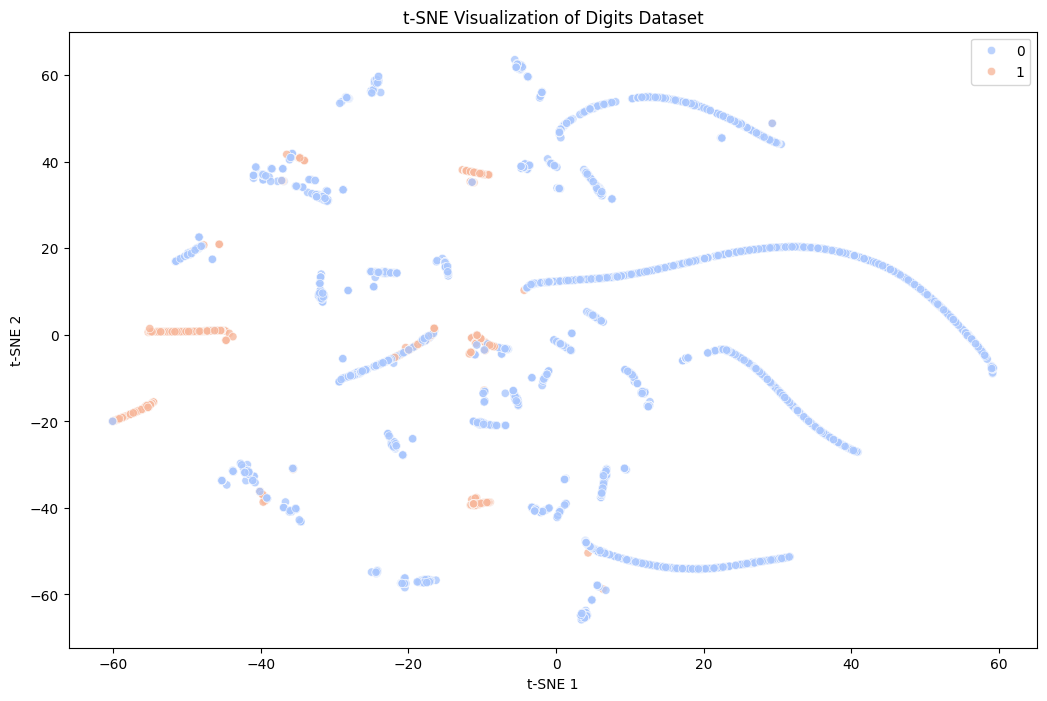

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import random as r

# Plot
fig, ax = plt.subplots(figsize=(12.5, 8))

sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_train, alpha=0.8, palette='coolwarm')#, legend=0)
ax.set_title("t-SNE Visualization of Digits Dataset")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.show()

In [68]:
import os
import re
from ase.io import read
from ase import Atoms
import numpy as np
import random as r
import sys

def near(atomnum, atoms, tolerance=2.000, Cfirst=True):
    atoms_not_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
    mole = [atomnum]
    pre_distances = atoms.get_distances(atomnum, atoms_not_H)
    distances = np.delete(pre_distances, np.where(pre_distances >= tolerance))
    distances = np.delete(distances, np.where(distances == 0))
    distances.sort()
    length = len(distances)
    if length > 4:
        distances = distances[:4]
    for i, atom in enumerate(atoms_not_H):
        distance = atoms.get_distance(atom, atomnum)
        if distance in distances:
            mole.append(atom)
    mole_C = []
    mole_other = []
    for num in mole:
        if atoms[num].symbol == 'C':
            mole_C.append(num)
        else:
            mole_other.append(num)
    if len(distances) == 1:
        if atoms[atomnum].symbol == 'C':
            return mole_C + mole_other
        else:
            return mole_other + mole_C
    if Cfirst == True:
        return mole_C + mole_other
    else:
        return mole_other + mole_C

def allone(lists):
    judge_box = []
    for ls in lists:
        for i in ls:
            judge_box.append(i)
    if 0 in judge_box:
        return 0
    else:
        return 1

def allroutes(file, loc='./', atomnums=[0,1], tolerance=2.000,\
              form='XYZ', Cfirst=True, ignores=[], verbose=False):
    passeds = []
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    atomnum1 = atomnums[0]
    atomnum2 = atomnums[1]
    atoms_not_H = []
    atoms_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
        else:
            atoms_H.append(i)
    
    #Trace Back
    step = 1
    z = 1
    i = 1
    passed = []
    routes = []
    real_moles = []
    route = [atomnum1]
    while 1:
        mole = near(atomnum1, atoms, tolerance=tolerance, Cfirst=Cfirst)
        if verbose == True:
            print('Near:', mole)
        real_mole = [*mole]
        real_mole.remove(atomnum1)
        real_moles.append(real_mole)
        passed = [0]*len(real_mole)
        passeds.append(passed)
        
        if verbose == True:
            print(1)
            print('Real Near:', real_mole)
            print('Passed:', passeds)
            print('Number:', real_moles)
            print('Route:', route)
            print()
        
        for i,p in enumerate(passeds[step-1]):
            if real_moles[step-1][i] in ignores:
                passeds[step-1][i] = 1
            if real_moles[step-1][i] in route:
                passeds[step-1][i] = 1
        
        if allone(passeds) == 1:
            break
        
        while 0 not in passeds[step-1]:
            del passeds[-1]
            step = step - 1
            del route[-1]
            del real_moles[-1]
        
        for j, p in enumerate(passeds[step-1]):
            if p == 0:
                break
        
        passeds[step-1][j] = 1
        atomnum1 = real_moles[step-1][j]
        route.append(atomnum1)
        if verbose == True:
            print(2)
            print('Real Near:', real_moles[step-1])
            print('Passed:', passeds)
            print('Number:', real_moles)
            print('Route:', route)
            print()
        
        if route[-1] == atomnum2:
            print('\nCorrect Route:', route)
            routes.append([*route])
            print('\n')
        
        step = step + 1

        z = z + 1
    if verbose == True:
        print(z, 'steps to find these routes.')
        print('Routes:', routes)
    os.chdir(opath)
    return routes

def routelength(file, a, loc='./'):
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    distance = 0
    for i in range(len(a)-1):
        x1 = a[0]
        x2 = a[1]
        distance = distance + atoms.get_distances(x1, x2)[0]
    os.chdir(opath)
    return distance

In [69]:
# Find Routes

from ase.io import read

j = 85
print('Result of {0}:\n'.format(Molnums[j]))

loc = './Extra/'
atom1 = Atom1s[j]
atom2 = Atom2s[j]
    
print('Force Sites:',atom1, atom2)

all_routes = allroutes(Molnums[j]+'_0.0', loc=loc, atomnums=[atom1, atom2], tolerance=2.000,\
                        form='XYZ', Cfirst=True)

minimum_routes = []
routes_distances = [len(route) for route in all_routes]
min_routes_distance = min(routes_distances)

print(min([len(route) for route in all_routes]), 'atoms in Minimum route.')

for route in all_routes:
    if len(route) == min_routes_distance:
        minimum_routes.append(route)

print('All Minimum Routes:')
for route in minimum_routes:
    print(route)

and_minimum_routes = []

if len(minimum_routes) > 1:
    for i in range(len(minimum_routes[0])):
        xo = 1
        for k in range(len(minimum_routes)-1):
            if minimum_routes[0][i] not in minimum_routes[k+1]:
                xo = 0
        if xo == 1:
            and_minimum_routes.append(minimum_routes[0][i])
else:
    and_minimum_routes = minimum_routes[0]

print()
print('Candidates:')
print(and_minimum_routes)

Result of 4014:

Force Sites: 6 7

Correct Route: [6, 7]


2 atoms in Minimum route.
All Minimum Routes:
[6, 7]

Candidates:
[6, 7]


In [73]:
#### !!!!

f = open('Force_candidate_transfer_all.csv', 'r')

mols = []
lists = []

for line in f:
    if 'Molecule' in line:
        continue
    a = re.split(',', line)
    mols.append(a[0])
    a = re.search(r'\[.*?\]', line)
    if a:
        lists.append(eval(a.group(0)))
    else:
        lists.append([])

def eleneg(ele):
    if ele == 'C':
        info = 2.55
    elif ele == 'O':
        info = 3.44
    elif ele == 'N':
        info = 3.04
    elif ele == 'S':
        info = 2.58
    elif ele == 'F':
        info = 4.00
    return info

def ringindex(ringnum):
    if 7 <= ringnum <= 99:
        return 7
    elif ringnum == 99999:
        return 0
    else:
        return ringnum

def bonds_in_route(atoms, ls, tolerance=1.7):
    lengths = []
    pair_ele = []
    pair_num = []
    lengths_with_S = []
    pair_ele_with_S = []
    pair_num_with_S = []
    for i,atom in enumerate(ls):
        if i >= len(ls) - 1:
            break
        num1 = ls[i]
        num2 = ls[i+1]
        ele1 = atoms.get_chemical_symbols()[num1]
        ele2 = atoms.get_chemical_symbols()[num2]
        d = atoms.get_distances(num1, num2)
        if 'S' in [ele1, ele2]:
            if d > tolerance + 0.45:
                continue
            else:
                lengths_with_S.append(d)
                pair_ele_with_S.append([ele1, ele2])
                pair_num_with_S.append([num1, num2])
        else:
            if d > tolerance:
                continue
            else:
                lengths.append(d)
                pair_ele.append([ele1, ele2])
                pair_num.append([num1, num2])
    return lengths, pair_ele, pair_num, lengths_with_S, pair_ele_with_S, pair_num_with_S

def standardise_bonds(lengths, pair_ele):
    CC = 1.528
    CO = 1.407
    CN = 1.457
    OO = 1.442
    NN = 1.473
    NO = 1.431
    SS = 2.100
    SO = 1.690
    SN = 1.734
    SC = 1.830
    standardised_lengths = []
    for i, length in enumerate(lengths):
        if {*pair_ele[i]} == {'C', 'C'}:
            standardised_lengths.append(length / CC)
        elif {*pair_ele[i]} == {'N', 'N'}:
            standardised_lengths.append(length / NN)
        elif {*pair_ele[i]} == {'O', 'O'}:
            standardised_lengths.append(length / OO)
        elif {*pair_ele[i]} == {'C', 'O'}:
            standardised_lengths.append(length / CO)
        elif {*pair_ele[i]} == {'C', 'N'}:
            standardised_lengths.append(length / CN)
        elif {*pair_ele[i]} == {'O', 'N'}:
            standardised_lengths.append(length / NO)
        elif {*pair_ele[i]} == {'S', 'S'}:
            standardised_lengths.append(length / SS)
        elif {*pair_ele[i]} == {'S', 'N'}:
            standardised_lengths.append(length / SN)
        elif {*pair_ele[i]} == {'S', 'O'}:
            standardised_lengths.append(length / SO)
        elif {*pair_ele[i]} == {'S', 'C'}:
            standardised_lengths.append(length / SC)
        else:
            standardised_lengths.append(None)
    return standardised_lengths

def sulphur_result(pair_ele_with_S, pair_num_with_S, atoms):
    SS = 2.100
    SO = 1.690
    SN = 1.734
    SC = 1.830
    
    score = []
    cands = []
    cands_ele = []
    cands_length = []
    best_nums_S = []
    best_eles_S = []
    best_lengths_S = []
    
    real_length = -100.0
    for i,pair in enumerate(pair_ele_with_S):
        if pair == ['S', 'S']:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            if d / SS > real_length :
                real_length = d / SS
            cands.append(pair_ele_with_S[i])
            cands_length.append(d / SS)
        else:
            continue
    if cands != []:
        if len(cands) == 1:
            print('Broken Bonds:', cands)
            return cands
        for i, cand in enumerate(cands):
            if real_length - cands_length[i] < 0.01:
                best.append(cands)
        #print('Broken Bonds:', best)
        return best
    
    for i,pair in enumerate(pair_ele_with_S):
        if {*pair} == {'S', 'O'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SO > real_length:
                real_length = d / SO
            cands_length.append(d / SO)
            cands_ele.append(pair_ele_with_S[i])
        elif {*pair} == {'S', 'N'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SN > real_length:
                real_length = d / SN
            cands_length.append(d / SN)
            cands_ele.append(pair_ele_with_S[i])
        elif {*pair} == {'S', 'C'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SC > real_length:
                real_length = d / SC
            cands_length.append(d / SC)
            cands_ele.append(pair_ele_with_S[i])
        else:
            raise Exception('Current not support for other bonds with S.')
    
    if len(cands) == 1:
        #print('Broken Bonds:', cands)
        return cands
    #print(cands)
    #print(cands_length)
    #print(real_length)
    for i,cand in enumerate(cands):
        if real_length - cands_length[i] < 0.001:
            best_nums_S.append(cand)
            best_eles_S.append(cands_ele[i])
            best_lengths_S.append(cands_length[i])
    #print('Broken Bonds:', best_nums_S)
    
    return best_lengths_S, best_eles_S, best_nums_S

def filter_rank(file, ls, loc='./', tolerance=1.7, quick_S=True):
    atoms = read(loc+file+'.xyz')
    lengths, pair_ele, pair_num, lengths_with_S,\
    pair_ele_with_S, pair_num_with_S = bonds_in_route(atoms, ls, tolerance=tolerance)
    #print(lengths)
    #print(pair_ele)
    #print(pair_num)
    
    ## Rings Infos
    
    bonds = all_bonds(atoms, tolerance=1.7)[0]
    all_rings, conjs_ring = classify_nodes_by_cycles(len(atoms.get_chemical_symbols()), bonds, atoms, simplerings=True)
    #print(all_rings)
    #print(conjs_ring)
    
    ## Rings
    atoms_inring = []
    atoms_inconj = []
    eliminated_bonds = []
    tense_bonds = []
    
    for i, ring in enumerate(all_rings):
        if conjs_ring[i] == 1:
            for i, atom in enumerate(ring):
                if i == len(ring)-1:
                    break
                else:
                    a = ring[i]
                    b = ring[i+1]
                eliminated_bonds.append([a, b])
                eliminated_bonds.append([b, a])
                atoms_inconj.append(a)
        elif len(ring) <= 6:
            for i, atom in enumerate(ring):
                if i == len(ring)-1:
                    break
                else:
                    a = ring[i]
                    b = ring[i+1]
                tense_bonds.append([a, b])
                tense_bonds.append([b, a])
    
    #print(eliminated_bonds)
    ## Delete Bonds in Conjugative Rings
    eliminated_i = []
    for i, length in enumerate(lengths):
        if pair_num[i] in eliminated_bonds:
            eliminated_i.append(i)
    
    eliminated_i.reverse()
    for i in eliminated_i:
        del pair_num[i]
        del pair_ele[i]
        del lengths[i]
    
    eliminated_i = []
    for i, length in enumerate(lengths_with_S):
        if pair_num_with_S[i] in eliminated_bonds:
            eliminated_i.append(i)
    
    eliminated_i.reverse()
    
    for i in eliminated_i:
        #print(pair_num_with_S[i])
        del pair_num_with_S[i]
        del pair_ele_with_S[i]
        del lengths_with_S[i]
    
    ## Special: Get Result about Sulphur Bonds
    if pair_ele_with_S != [] and quick_S == True:
        #print(pair_ele_with_S)
        #print(pair_num_with_S)
        #print(lengths_with_S)
        return sulphur_result(pair_ele_with_S, pair_num_with_S, atoms)
    else:
        # Other Bonds
        pair_ele = pair_ele + pair_ele_with_S
        pair_num = pair_num + pair_num_with_S
        lengths = lengths + lengths_with_S
        #print(pair_ele)
        #print(pair_num)
        #print(lengths)
    
    ## Standardise Bonds
    standardised_lengths = standardise_bonds(lengths, pair_ele)
    
    ## Set Bonds in Other Ring:
    cand_bonds_tense = []
    
    cand_atoms_tense = []
    cand_atoms_conj = []
    
    for i, length in enumerate(lengths):
        # Atoms in Conjugative System
        atom_conj = []
        if pair_num[i][0] in atoms_inconj:
            atom_conj.append(1)
        else:
            atom_conj.append(0)
        if pair_num[i][1] in atoms_inconj:
            atom_conj.append(1)
        else:
            atom_conj.append(0)
        cand_atoms_conj.append(atom_conj)
        
        # Atoms and Bonds in rings
        minring1 = 99999
        minring2 = 99999
        minring3 = 99999
        for ring in all_rings:
            if pair_num[i][0] in ring and len(ring) - 1 < minring1:
                minring1 = len(ring) - 1
            if pair_num[i][1] in ring and len(ring) - 1 < minring2:
                minring2 = len(ring) - 1
            if (pair_num[i][0] in ring and pair_num[i][1] in ring) and len(ring) - 1 < minring3:
                minring3 = len(ring) - 1
        minring1 = ringindex(minring1)
        minring2 = ringindex(minring2)
        minring3 = ringindex(minring3)
        atom_ring = [minring1, minring2]
        cand_atoms_tense.append(atom_ring)
        cand_bonds_tense.append(minring3)
        
    ## Rank Pairs in rings and not in rings
    # Assemble
    assembles_normal = []
    assembles_tense = []
    SignS = 0
    for i, tense in enumerate(cand_bonds_tense):
        if SignS == 1 and (pair_ele[i][0] != 'S' and pair_ele[i][1] != 'S'):
            continue
        if SignS == 0 and (pair_ele[i][0] == 'S' or pair_ele[i][1] == 'S'):
            assembles_tense = []
            assembles_normal = []
            SignS = 1
        if tense > 0:
            assembles_tense.append([
                                    lengths[i],\
                                    standardised_lengths[i], cand_bonds_tense[i],\
                                    # Standardised Bond Length, Which Ring is Bond in?
                                    eleneg(pair_ele[i][0]), eleneg(pair_ele[i][1]), \
                                    # Electronegativity of Two Atoms
                                    *cand_atoms_conj[i], \
                                    # Are Two Atoms in Conjugative Rings?
                                    *cand_atoms_tense[i], \
                                    # Which Ring are Two Atoms in?
                                    
                                    # ? Need two charges here ?
                
                                    pair_num[i], \
                                    # Atoms Number
                                    i # Bond Number
                                   ]) # 8 Indexes in all
        else:
            assembles_normal.append([
                                    lengths[i],\
                                    standardised_lengths[i], cand_bonds_tense[i], \
                                    # Standardised Bond Length, Which Ring is Bond in?
                                    eleneg(pair_ele[i][0]), eleneg(pair_ele[i][1]), \
                                    # Electronegativity of Two Atoms
                                    *cand_atoms_conj[i], \
                                    # Are Two Atoms in Conjugative Rings?
                                    *cand_atoms_tense[i], \
                                    # Which Ring are Two Atoms in?
                                    
                                    # ? Need two charges here?
                                    
                                    pair_num[i], \
                                    # Atoms Number
                                    i
                                    # Bond Number
                                   ]) # 8 Indexes in all
    
    best_cands = []
    
    i = 0
    ## Tensed Bond for 4
    assembles_tense.sort()
    assembles_tense.reverse()
    for i0,assemble_tense in enumerate(assembles_tense):
        try:
            best_cands.append(assembles_tense[i0])
        except:
            break
        i = i + 1
    
    ## Other Bonds for 5
    #print('pre', assembles_normal)
    assembles_normal.sort()
    assembles_normal.reverse()
    #print(assembles_normal)
    x = 0
    for i0,assemble_normal in enumerate(assembles_normal):
        try:
            best_cands.append(assembles_normal[x])
        except:
            break
        i = i + 1
        x = x + 1
    
    print(f'\nTop {i} possible broken bonds:\n')
    i = 1
    for cand in best_cands:
        if pair_ele[cand[-1]] == ['F', 'C']:
            continue
        print(f'Bond {i}:')
        print('Bond Pair: {0:>10} ,    Bond Elements: {1:>10}'.format(str(pair_num[cand[-1]]), str(pair_ele[cand[-1]])))
        print('Length: {0:>10.4f} Å,   Standardised Length: {1:>10.4%}'.format(lengths[cand[-1]][0], cand[1][0]))
        print('Minimum Ring of bond: {0},'.format(str(cand[2])))
        print('Atom 1 is {0} conjugative ring.'.format('in' if cand[5] == 1 else 'not in'))
        print('Atom 2 is {0} conjugative ring.'.format('in' if cand[6] == 1 else 'not in'))
        print('Atom 1 is {0} ring.'.format('in {0}-membered'.format(cand[7]) if cand[7] != 0 else 'not in'))
        print('Atom 2 is {0} ring.'.format('in {0}-membered'.format(cand[8]) if cand[8] != 0 else 'not in'))
        print()
        i = i + 1
    
    return best_cands